In [1]:
import pandas as pd
import numpy as np

print("AI Readmission Prevention Model")
print("Environment ready.")

AI Readmission Prevention Model
Environment ready.


In [2]:
data = {
    "age": [67, 45, 82, 34, 59, 71, 50, 76, 63, 41],
    "length_of_stay": [5, 3, 8, 2, 6, 7, 4, 9, 5, 2],
    "previous_admissions": [2, 0, 4, 0, 3, 2, 1, 5, 2, 0],
    "chronic_conditions": [3, 1, 5, 0, 2, 4, 1, 6, 3, 0],
    "emergency_visit": [1, 0, 1, 0, 1, 1, 0, 1, 0, 0],
    "readmitted": [1, 0, 1, 0, 1, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

print("Synthetic patient dataset created.")

Synthetic patient dataset created.


In [3]:
df

,age,length_of_stay,previous_admissions,chronic_conditions,emergency_visit,readmitted
0,67,5,2,3,1,1
1,45,3,0,1,0,0
2,82,8,4,5,1,1
3,34,2,0,0,0,0
4,59,6,3,2,1,1
5,71,7,2,4,1,1
6,50,4,1,1,0,0
7,76,9,5,6,1,1
8,63,5,2,3,0,1
9,41,2,0,0,0,0


In [4]:
print("Number of patients:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of patients: 10
Number of variables: 6


In [5]:
df.isnull().sum()

age                    0
length_of_stay         0
previous_admissions    0
chronic_conditions     0
emergency_visit        0
readmitted             0
dtype: int64

In [6]:
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

print("Features (X):")
print(X)

print("\nTarget (y):")
print(y)

Features (X):
   age  length_of_stay  previous_admissions  chronic_conditions  \
0   67               5                    2                   3   
1   45               3                    0                   1   
2   82               8                    4                   5   
3   34               2                    0                   0   
4   59               6                    3                   2   
5   71               7                    2                   4   
6   50               4                    1                   1   
7   76               9                    5                   6   
8   63               5                    2                   3   
9   41               2                    0                   0   

   emergency_visit  
0                1  
1                0  
2                1  
3                0  
4                1  
5                1  
6                0  
7                1  
8                0  
9                0  

Target (y):
0   

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training patients:", len(X_train))
print("Testing patients:", len(X_test))

Training patients: 7
Testing patients: 3


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

print("AI model created.")

AI model created.


In [9]:
model.fit(X_train, y_train)

print("AI model trained successfully.")

AI model trained successfully.


In [10]:
predictions = model.predict(X_test)

print("Predictions:")
print(predictions)

Predictions:
[1 0 1]


In [11]:
print("Actual outcomes:")
print(y_test.to_numpy())

Actual outcomes:
[1 0 1]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model accuracy:", accuracy)
print("Model accuracy (%):", accuracy * 100)

Model accuracy: 1.0
Model accuracy (%): 100.0


In [13]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,age,0.548371
1,length_of_stay,0.119272
2,previous_admissions,0.118963
3,chronic_conditions,0.061032
4,emergency_visit,0.059790


In [14]:
np.random.seed(42)

num_patients = 1000

large_data = {
    "age": np.random.randint(18, 90, num_patients),
    "length_of_stay": np.random.randint(1, 15, num_patients),
    "previous_admissions": np.random.randint(0, 6, num_patients),
    "chronic_conditions": np.random.randint(0, 7, num_patients),
    "emergency_visit": np.random.randint(0, 2, num_patients)
}

large_df = pd.DataFrame(large_data)

print("Synthetic dataset created.")
print("Number of patients:", len(large_df))

Synthetic dataset created.
Number of patients: 1000


In [15]:
risk_score = (
    -3.0
    + 0.025 * large_df["age"]
    + 0.18 * large_df["length_of_stay"]
    + 0.35 * large_df["previous_admissions"]
    + 0.30 * large_df["chronic_conditions"]
    + 0.70 * large_df["emergency_visit"]
)

readmission_probability = 1 / (1 + np.exp(-risk_score))

large_df["readmitted"] = np.random.binomial(
    1,
    readmission_probability
)

print("Readmission outcomes created.")
print(large_df["readmitted"].value_counts())

Readmission outcomes created.
1    812
0    188
Name: readmitted, dtype: int64


In [16]:
large_df.head(10)

,age,length_of_stay,previous_admissions,chronic_conditions,emergency_visit,readmitted
0,69,7,1,3,1,1
1,32,13,4,5,1,1
2,89,8,0,3,1,0
3,78,1,4,1,0,1
4,38,9,5,6,1,1
5,41,7,4,2,1,1
6,20,3,5,4,1,0
7,39,8,1,2,1,0
8,70,7,0,2,0,0
9,19,11,1,1,1,0


In [17]:
readmission_rate = large_df["readmitted"].mean() * 100

print(f"Readmission rate: {readmission_rate:.1f}%")

Readmission rate: 81.2%


In [18]:
risk_score = (
    -4.5
    + 0.025 * large_df["age"]
    + 0.12 * large_df["length_of_stay"]
    + 0.25 * large_df["previous_admissions"]
    + 0.20 * large_df["chronic_conditions"]
    + 0.45 * large_df["emergency_visit"]
)

readmission_probability = 1 / (1 + np.exp(-risk_score))

large_df["readmitted"] = np.random.binomial(
    1,
    readmission_probability
)

print("Updated readmission outcomes created.")
print(large_df["readmitted"].value_counts())

readmission_rate = large_df["readmitted"].mean() * 100
print(f"Readmission rate: {readmission_rate:.1f}%")

Updated readmission outcomes created.
0    666
1    334
Name: readmitted, dtype: int64
Readmission rate: 33.4%


In [19]:
print("Dataset shape:", large_df.shape)
print("\nMissing values:")
print(large_df.isnull().sum())

Dataset shape: (1000, 6)

Missing values:
age                    0
length_of_stay         0
previous_admissions    0
chronic_conditions     0
emergency_visit        0
readmitted             0
dtype: int64


In [20]:
X_large = large_df.drop("readmitted", axis=1)
y_large = large_df["readmitted"]

print("Features:", X_large.shape)
print("Target:", y_large.shape)

Features: (1000, 5)
Target: (1000,)


In [21]:
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(
    X_large,
    y_large,
    test_size=0.2,
    random_state=42,
    stratify=y_large
)

print("Training patients:", len(X_train_large))
print("Testing patients:", len(X_test_large))

Training patients: 800
Testing patients: 200


In [22]:
large_model = LogisticRegression(max_iter=1000)

print("Larger AI model created.")

Larger AI model created.


In [23]:
large_model.fit(X_train_large, y_train_large)

print("Larger AI model trained successfully.")

Larger AI model trained successfully.


In [24]:
large_predictions = large_model.predict(X_test_large)

print("Number of predictions:", len(large_predictions))
print("First 20 predictions:")
print(large_predictions[:20])

Number of predictions: 200
First 20 predictions:
[0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 1]


In [25]:
large_accuracy = accuracy_score(y_test_large, large_predictions)

print("Model accuracy:", large_accuracy)
print("Model accuracy (%):", large_accuracy * 100)

Model accuracy: 0.72
Model accuracy (%): 72.0


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_large, large_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[113  20]
 [ 36  31]]


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_large, large_predictions)
recall = recall_score(y_test_large, large_predictions)
f1 = f1_score(y_test_large, large_predictions)

print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Precision: 0.608
Recall: 0.463
F1 Score: 0.525


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test_large, large_predictions))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       133
           1       0.61      0.46      0.53        67

    accuracy                           0.72       200
   macro avg       0.68      0.66      0.66       200
weighted avg       0.71      0.72      0.71       200



In [29]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train_large, y_train_large)

baseline_predictions = baseline_model.predict(X_test_large)

baseline_accuracy = accuracy_score(y_test_large, baseline_predictions)

print("Baseline accuracy:", round(baseline_accuracy, 3))
print("Baseline accuracy (%):", round(baseline_accuracy * 100, 1))

Baseline accuracy: 0.665
Baseline accuracy (%): 66.5


In [30]:
large_probabilities = large_model.predict_proba(X_test_large)[:, 1]

print("First 20 predicted readmission probabilities:")
print(np.round(large_probabilities[:20], 3))

First 20 predicted readmission probabilities:
[0.113 0.607 0.098 0.1   0.296 0.277 0.194 0.6   0.639 0.804 0.254 0.176
 0.275 0.279 0.091 0.276 0.589 0.524 0.14  0.639]


In [31]:
threshold = 0.30

threshold_predictions = (large_probabilities >= threshold).astype(int)

threshold_precision = precision_score(y_test_large, threshold_predictions)
threshold_recall = recall_score(y_test_large, threshold_predictions)
threshold_f1 = f1_score(y_test_large, threshold_predictions)

print("Threshold:", threshold)
print("Precision:", round(threshold_precision, 3))
print("Recall:", round(threshold_recall, 3))
print("F1 Score:", round(threshold_f1, 3))

Threshold: 0.3
Precision: 0.505
Recall: 0.761
F1 Score: 0.607


In [32]:
comparison = pd.DataFrame({
    "Threshold": ["50% (Default)", "30%"],
    "Precision": [precision, threshold_precision],
    "Recall": [recall, threshold_recall],
    "F1 Score": [f1, threshold_f1]
})

comparison

,Threshold,Precision,Recall,F1 Score
0,50% (Default),0.607843,0.462687,0.525424
1,30%,0.504950,0.761194,0.607143


In [33]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
    predictions_at_threshold = (
        large_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test_large,
            predictions_at_threshold
        ),
        "Recall": recall_score(
            y_test_large,
            predictions_at_threshold
        ),
        "F1 Score": f1_score(
            y_test_large,
            predictions_at_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.20,0.425532,0.895522,0.576923
1,0.25,0.475000,0.850746,0.609626
2,0.30,0.504950,0.761194,0.607143
3,0.35,0.536585,0.656716,0.590604
4,0.40,0.577465,0.611940,0.594203
5,0.45,0.614035,0.522388,0.564516
6,0.50,0.607843,0.462687,0.525424


In [34]:
from sklearn.metrics import confusion_matrix

cm_30 = confusion_matrix(y_test_large, threshold_predictions)

print("Confusion Matrix at 30% Threshold:")
print(cm_30)

Confusion Matrix at 30% Threshold:
[[83 50]
 [16 51]]


In [35]:
patients_flagged = threshold_predictions.sum()
total_test_patients = len(threshold_predictions)

print("Patients flagged for intervention:", patients_flagged)
print("Total test patients:", total_test_patients)
print(
    "Percentage of test patients flagged:",
    round((patients_flagged / total_test_patients) * 100, 1),
    "%"
)

Patients flagged for intervention: 101
Total test patients: 200
Percentage of test patients flagged: 50.5 %


In [36]:
workload_results = []

for threshold in [0.25, 0.30, 0.35, 0.40]:
    predictions_at_threshold = (
        large_probabilities >= threshold
    ).astype(int)

    flagged = predictions_at_threshold.sum()
    recall_value = recall_score(
        y_test_large,
        predictions_at_threshold
    )

    workload_results.append({
        "Threshold": threshold,
        "Patients Flagged": flagged,
        "Percent Flagged": (flagged / len(predictions_at_threshold)) * 100,
        "Recall": recall_value * 100
    })

workload_df = pd.DataFrame(workload_results)

workload_df

,Threshold,Patients Flagged,Percent Flagged,Recall
0,0.25,120,60.0,85.074627
1,0.30,101,50.5,76.119403
2,0.35,82,41.0,65.671642
3,0.40,71,35.5,61.194030


In [37]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best threshold by F1 Score:")
print(best_threshold_row)

Best threshold by F1 Score:
Threshold    0.250000
Precision    0.475000
Recall       0.850746
F1 Score     0.609626
Name: 1, dtype: float64


In [38]:
large_coefficients = pd.DataFrame({
    "Feature": X_large.columns,
    "Coefficient": large_model.coef_[0]
})

large_coefficients

,Feature,Coefficient
0,age,0.024174
1,length_of_stay,0.138779
2,previous_admissions,0.244869
3,chronic_conditions,0.165520
4,emergency_visit,0.607791


In [39]:
large_coefficients["Absolute Impact"] = (
    large_coefficients["Coefficient"].abs()
)

large_coefficients.sort_values(
    "Absolute Impact",
    ascending=False
)

,Feature,Coefficient,Absolute Impact
4,emergency_visit,0.607791,0.607791
2,previous_admissions,0.244869,0.244869
3,chronic_conditions,0.165520,0.165520
1,length_of_stay,0.138779,0.138779
0,age,0.024174,0.024174


In [40]:
model_summary = {
    "Test Patients": len(y_test_large),
    "Accuracy": large_accuracy,
    "Precision (50% threshold)": precision,
    "Recall (50% threshold)": recall,
    "F1 (50% threshold)": f1,
    "Precision (30% threshold)": threshold_precision,
    "Recall (30% threshold)": threshold_recall,
    "F1 (30% threshold)": threshold_f1,
    "Best F1 Threshold": best_threshold_row["Threshold"],
    "Best F1 Score": best_threshold_row["F1 Score"]
}

model_summary

{'Test Patients': 200,
 'Accuracy': 0.72,
 'Precision (50% threshold)': 0.6078431372549019,
 'Recall (50% threshold)': 0.4626865671641791,
 'F1 (50% threshold)': 0.5254237288135594,
 'Precision (30% threshold)': 0.504950495049505,
 'Recall (30% threshold)': 0.7611940298507462,
 'F1 (30% threshold)': 0.6071428571428572,
 'Best F1 Threshold': 0.25,
 'Best F1 Score': 0.6096256684491979}

In [41]:
print("Training set class distribution:")
print(y_train_large.value_counts())

print("\nTraining set percentages:")
print(y_train_large.value_counts(normalize=True) * 100)

Training set class distribution:
0    533
1    267
Name: readmitted, dtype: int64

Training set percentages:
0    66.625
1    33.375
Name: readmitted, dtype: float64


In [42]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

print("Random Forest model created.")

Random Forest model created.


In [43]:
random_forest_model.fit(X_train_large, y_train_large)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [44]:
rf_predictions = random_forest_model.predict(X_test_large)

print("Number of predictions:", len(rf_predictions))
print("First 20 predictions:")
print(rf_predictions[:20])

Number of predictions: 200
First 20 predictions:
[0 0 0 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 0 1]


In [45]:
rf_accuracy = accuracy_score(y_test_large, rf_predictions)

print("Random Forest accuracy:", rf_accuracy)
print("Random Forest accuracy (%):", rf_accuracy * 100)

Random Forest accuracy: 0.69
Random Forest accuracy (%): 69.0


In [46]:
rf_precision = precision_score(y_test_large, rf_predictions)
rf_recall = recall_score(y_test_large, rf_predictions)
rf_f1 = f1_score(y_test_large, rf_predictions)

print("Random Forest Precision:", round(rf_precision, 3))
print("Random Forest Recall:", round(rf_recall, 3))
print("Random Forest F1 Score:", round(rf_f1, 3))

Random Forest Precision: 0.556
Random Forest Recall: 0.373
Random Forest F1 Score: 0.446


In [47]:
balanced_rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

print("Balanced Random Forest model created.")

Balanced Random Forest model created.


In [48]:
balanced_rf_model.fit(X_train_large, y_train_large)

print("Balanced Random Forest model trained successfully.")

Balanced Random Forest model trained successfully.


In [49]:
balanced_rf_predictions = balanced_rf_model.predict(X_test_large)

print("Number of predictions:", len(balanced_rf_predictions))
print("First 20 predictions:")
print(balanced_rf_predictions[:20])

Number of predictions: 200
First 20 predictions:
[0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1]


In [50]:
balanced_rf_accuracy = accuracy_score(
    y_test_large,
    balanced_rf_predictions
)

balanced_rf_precision = precision_score(
    y_test_large,
    balanced_rf_predictions
)

balanced_rf_recall = recall_score(
    y_test_large,
    balanced_rf_predictions
)

balanced_rf_f1 = f1_score(
    y_test_large,
    balanced_rf_predictions
)

print("Balanced Random Forest Accuracy:", round(balanced_rf_accuracy, 3))
print("Balanced Random Forest Precision:", round(balanced_rf_precision, 3))
print("Balanced Random Forest Recall:", round(balanced_rf_recall, 3))
print("Balanced Random Forest F1 Score:", round(balanced_rf_f1, 3))

Balanced Random Forest Accuracy: 0.675
Balanced Random Forest Precision: 0.524
Balanced Random Forest Recall: 0.328
Balanced Random Forest F1 Score: 0.404


In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_model = LogisticRegression(max_iter=1000)

print("Cross-validation setup complete.")

Cross-validation setup complete.


In [52]:
cv_scores = cross_val_score(
    cv_model,
    X_train_large,
    y_train_large,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation accuracy scores:")
print(np.round(cv_scores, 3))

print("Mean cross-validation accuracy:", round(cv_scores.mean(), 3))
print("Standard deviation:", round(cv_scores.std(), 3))

Cross-validation accuracy scores:
[0.712 0.694 0.694 0.731 0.725]
Mean cross-validation accuracy: 0.711
Standard deviation: 0.016


In [53]:
cv_recall_scores = cross_val_score(
    cv_model,
    X_train_large,
    y_train_large,
    cv=cv,
    scoring="recall"
)

print("Cross-validation recall scores:")
print(np.round(cv_recall_scores, 3))

print("Mean cross-validation recall:", round(cv_recall_scores.mean(), 3))
print("Standard deviation:", round(cv_recall_scores.std(), 3))

Cross-validation recall scores:
[0.377 0.377 0.321 0.37  0.389]
Mean cross-validation recall: 0.367
Standard deviation: 0.024


In [54]:
cv_f1_scores = cross_val_score(
    cv_model,
    X_train_large,
    y_train_large,
    cv=cv,
    scoring="f1"
)

print("Cross-validation F1 scores:")
print(np.round(cv_f1_scores, 3))

print("Mean cross-validation F1:", round(cv_f1_scores.mean(), 3))
print("Standard deviation:", round(cv_f1_scores.std(), 3))

Cross-validation F1 scores:
[0.465 0.449 0.41  0.482 0.488]
Mean cross-validation F1: 0.459
Standard deviation: 0.028


In [55]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        large_accuracy,
        rf_accuracy,
        balanced_rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        balanced_rf_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        balanced_rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        balanced_rf_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.720,0.607843,0.462687,0.525424
1,Random Forest,0.690,0.555556,0.373134,0.446429
2,Balanced Random Forest,0.675,0.523810,0.328358,0.403670


In [56]:
final_model = large_model

print("Final model candidate: Logistic Regression")

Final model candidate: Logistic Regression


In [57]:
final_probabilities = final_model.predict_proba(X_test_large)[:, 1]

print("First 20 final model probabilities:")
print(np.round(final_probabilities[:20], 3))

First 20 final model probabilities:
[0.113 0.607 0.098 0.1   0.296 0.277 0.194 0.6   0.639 0.804 0.254 0.176
 0.275 0.279 0.091 0.276 0.589 0.524 0.14  0.639]


In [58]:
risk_categories = np.select(
    [
        final_probabilities < 0.30,
        final_probabilities < 0.50
    ],
    [
        "Low Risk",
        "Moderate Risk"
    ],
    default="High Risk"
)

print("Risk categories created.")
print(pd.Series(risk_categories).value_counts())

Risk categories created.
Low Risk         99
High Risk        51
Moderate Risk    50
dtype: int64


In [59]:
risk_analysis = pd.DataFrame({
    "Risk Category": risk_categories,
    "Actual Readmission": y_test_large.values
})

risk_summary = risk_analysis.groupby("Risk Category")["Actual Readmission"].agg(
    ["count", "sum", "mean"]
)

risk_summary.columns = [
    "Patients",
    "Actual Readmissions",
    "Readmission Rate"
]

risk_summary["Readmission Rate"] = risk_summary["Readmission Rate"] * 100

risk_summary = risk_summary.reindex(
    ["Low Risk", "Moderate Risk", "High Risk"]
)

risk_summary

,Patients,Actual Readmissions,Readmission Rate
Risk Category,,,
Low Risk,99,16,16.161616
Moderate Risk,50,20,40.000000
High Risk,51,31,60.784314


In [60]:
low_risk_rate = risk_summary.loc["Low Risk", "Readmission Rate"]
high_risk_rate = risk_summary.loc["High Risk", "Readmission Rate"]

risk_difference = high_risk_rate - low_risk_rate
risk_ratio = high_risk_rate / low_risk_rate

print("Low Risk readmission rate:", round(low_risk_rate, 1), "%")
print("High Risk readmission rate:", round(high_risk_rate, 1), "%")
print("Difference:", round(risk_difference, 1), "percentage points")
print("Risk ratio:", round(risk_ratio, 2), "x")

Low Risk readmission rate: 16.2 %
High Risk readmission rate: 60.8 %
Difference: 44.6 percentage points
Risk ratio: 3.76 x


In [61]:
test_readmission_rate = y_test_large.mean() * 100

print("Actual test-set readmission rate:", round(test_readmission_rate, 1), "%")

Actual test-set readmission rate: 33.5 %


In [62]:
risk_summary["Compared With Overall"] = (
    risk_summary["Readmission Rate"] - test_readmission_rate
)

risk_summary

,Patients,Actual Readmissions,Readmission Rate,Compared With Overall
Risk Category,,,,
Low Risk,99,16,16.161616,-17.338384
Moderate Risk,50,20,40.000000,6.500000
High Risk,51,31,60.784314,27.284314


In [63]:
risk_summary_display = risk_summary.copy()

risk_summary_display["Readmission Rate"] = (
    risk_summary_display["Readmission Rate"].round(1)
)

risk_summary_display["Compared With Overall"] = (
    risk_summary_display["Compared With Overall"].round(1)
)

risk_summary_display

,Patients,Actual Readmissions,Readmission Rate,Compared With Overall
Risk Category,,,,
Low Risk,99,16,16.2,-17.3
Moderate Risk,50,20,40.0,6.5
High Risk,51,31,60.8,27.3


In [64]:
total_actual_readmissions = risk_summary["Actual Readmissions"].sum()

risk_summary["Percent of Actual Readmissions"] = (
    risk_summary["Actual Readmissions"] / total_actual_readmissions * 100
)

risk_summary["Percent of Actual Readmissions"] = (
    risk_summary["Percent of Actual Readmissions"].round(1)
)

risk_summary

,Patients,Actual Readmissions,Readmission Rate,Compared With Overall,Percent of Actual Readmissions
Risk Category,,,,,
Low Risk,99,16,16.161616,-17.338384,23.9
Moderate Risk,50,20,40.000000,6.500000,29.9
High Risk,51,31,60.784314,27.284314,46.3


In [65]:
high_risk_patients = risk_summary.loc["High Risk", "Patients"]
high_risk_readmissions = risk_summary.loc["High Risk", "Actual Readmissions"]

high_risk_capture_rate = (
    high_risk_readmissions / total_actual_readmissions * 100
)

high_risk_population_percentage = (
    high_risk_patients / len(y_test_large) * 100
)

print("High Risk patients:", high_risk_patients)
print("High Risk group size:", round(high_risk_population_percentage, 1), "%")
print("Actual readmissions captured:", high_risk_readmissions)
print("Readmissions captured:", round(high_risk_capture_rate, 1), "%")

High Risk patients: 51
High Risk group size: 25.5 %
Actual readmissions captured: 31
Readmissions captured: 46.3 %


In [66]:
intervention_efficiency = (
    high_risk_capture_rate / high_risk_population_percentage
)

print("Percentage of patients targeted:", round(high_risk_population_percentage, 1), "%")
print("Percentage of readmissions captured:", round(high_risk_capture_rate, 1), "%")
print(
    "Intervention concentration ratio:",
    round(intervention_efficiency, 2),
    "x"
)

Percentage of patients targeted: 25.5 %
Percentage of readmissions captured: 46.3 %
Intervention concentration ratio: 1.81 x


In [67]:
model_findings = {
    "Test Patients": len(y_test_large),
    "Test Readmission Rate": round(test_readmission_rate, 1),
    "Best Model": "Logistic Regression",
    "Test Accuracy": round(large_accuracy * 100, 1),
    "Test Precision (50% Threshold)": round(precision * 100, 1),
    "Test Recall (50% Threshold)": round(recall * 100, 1),
    "Test F1 (50% Threshold)": round(f1 * 100, 1),
    "Best F1 Threshold": 0.25,
    "Best F1 Score": round(0.6096256684491979 * 100, 1),
    "Low Risk Readmission Rate": round(
        risk_summary.loc["Low Risk", "Readmission Rate"], 1
    ),
    "Moderate Risk Readmission Rate": round(
        risk_summary.loc["Moderate Risk", "Readmission Rate"], 1
    ),
    "High Risk Readmission Rate": round(
        risk_summary.loc["High Risk", "Readmission Rate"], 1
    ),
    "High vs Low Risk Ratio": round(risk_ratio, 2),
    "High Risk Population": round(high_risk_population_percentage, 1),
    "High Risk Readmissions Captured": round(high_risk_capture_rate, 1),
    "Intervention Concentration Ratio": round(intervention_efficiency, 2)
}

model_findings

{'Test Patients': 200,
 'Test Readmission Rate': 33.5,
 'Best Model': 'Logistic Regression',
 'Test Accuracy': 72.0,
 'Test Precision (50% Threshold)': 60.8,
 'Test Recall (50% Threshold)': 46.3,
 'Test F1 (50% Threshold)': 52.5,
 'Best F1 Threshold': 0.25,
 'Best F1 Score': 61.0,
 'Low Risk Readmission Rate': 16.2,
 'Moderate Risk Readmission Rate': 40.0,
 'High Risk Readmission Rate': 60.8,
 'High vs Low Risk Ratio': 3.76,
 'High Risk Population': 25.5,
 'High Risk Readmissions Captured': 46.3,
 'Intervention Concentration Ratio': 1.81}

In [68]:
cross_validation_findings = {
    "Folds": 5,
    "Mean Accuracy": round(cv_scores.mean() * 100, 1),
    "Accuracy Standard Deviation": round(cv_scores.std() * 100, 1),
    "Mean Recall": round(cv_recall_scores.mean() * 100, 1),
    "Recall Standard Deviation": round(cv_recall_scores.std() * 100, 1),
    "Mean F1": round(cv_f1_scores.mean() * 100, 1),
    "F1 Standard Deviation": round(cv_f1_scores.std() * 100, 1)
}

cross_validation_findings

{'Folds': 5,
 'Mean Accuracy': 71.1,
 'Accuracy Standard Deviation': 1.6,
 'Mean Recall': 36.7,
 'Recall Standard Deviation': 2.4,
 'Mean F1': 45.9,
 'F1 Standard Deviation': 2.8}

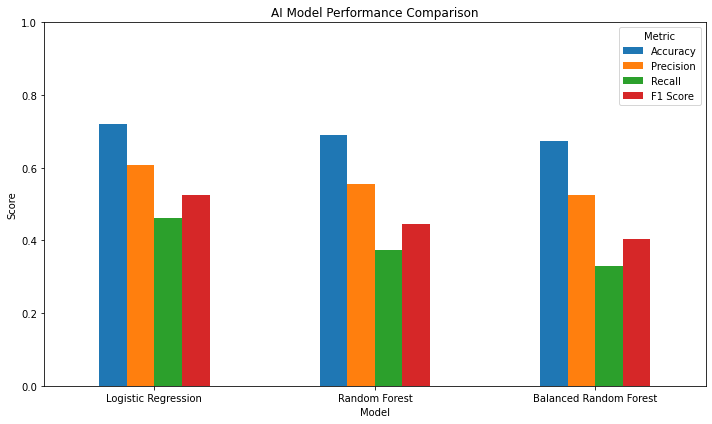

In [70]:
import matplotlib.pyplot as plt

model_comparison_plot = model_comparison.set_index("Model")

model_comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("AI Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

In [71]:
final_performance_summary = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1 Score",
        "Cross-Validation Accuracy",
        "Cross-Validation Recall",
        "Cross-Validation F1 Score"
    ],
    "Value": [
        f"{large_accuracy * 100:.1f}%",
        f"{precision * 100:.1f}%",
        f"{recall * 100:.1f}%",
        f"{f1 * 100:.1f}%",
        f"{cv_scores.mean() * 100:.1f}%",
        f"{cv_recall_scores.mean() * 100:.1f}%",
        f"{cv_f1_scores.mean() * 100:.1f}%"
    ]
})

final_performance_summary

,Metric,Value
0,Test Accuracy,72.0%
1,Test Precision,60.8%
2,Test Recall,46.3%
3,Test F1 Score,52.5%
4,Cross-Validation Accuracy,71.1%
5,Cross-Validation Recall,36.7%
6,Cross-Validation F1 Score,45.9%


In [73]:
threshold_summary = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

threshold_summary

,Threshold,Precision,Recall,F1 Score
0,0.20,0.425532,0.895522,0.576923
1,0.25,0.475000,0.850746,0.609626
2,0.30,0.504950,0.761194,0.607143
3,0.35,0.536585,0.656716,0.590604
4,0.40,0.577465,0.611940,0.594203
5,0.45,0.614035,0.522388,0.564516
6,0.50,0.607843,0.462687,0.525424


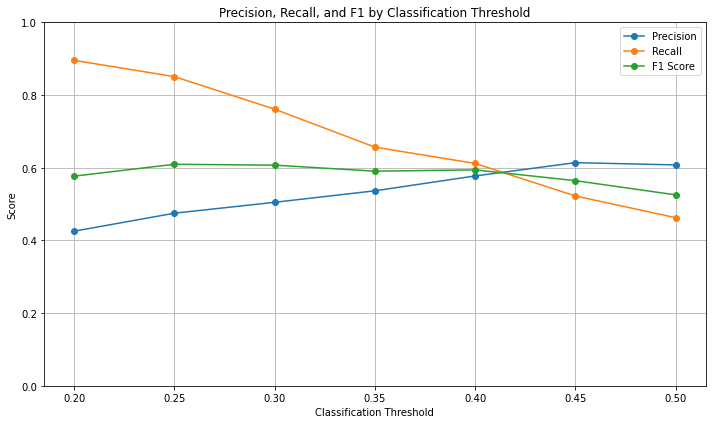

In [74]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_summary["Threshold"],
    threshold_summary["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_summary["Threshold"],
    threshold_summary["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_summary["Threshold"],
    threshold_summary["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.title("Precision, Recall, and F1 by Classification Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [75]:
best_threshold_row = threshold_summary.loc[
    threshold_summary["F1 Score"].idxmax()
]

print("Recommended prototype threshold:", best_threshold_row["Threshold"])
print("Precision:", round(best_threshold_row["Precision"] * 100, 1), "%")
print("Recall:", round(best_threshold_row["Recall"] * 100, 1), "%")
print("F1 Score:", round(best_threshold_row["F1 Score"] * 100, 1), "%")

Recommended prototype threshold: 0.25
Precision: 47.5 %
Recall: 85.1 %
F1 Score: 61.0 %


In [76]:
prototype_threshold = best_threshold_row["Threshold"]

prototype_predictions = (
    final_model.predict_proba(X_test_large)[:, 1] >= prototype_threshold
).astype(int)

patients_flagged_25 = prototype_predictions.sum()
percent_flagged_25 = patients_flagged_25 / len(y_test_large) * 100

print("Prototype threshold:", prototype_threshold)
print("Patients flagged for intervention:", patients_flagged_25)
print("Total test patients:", len(y_test_large))
print("Percentage of patients flagged:", round(percent_flagged_25, 1), "%")

Prototype threshold: 0.25
Patients flagged for intervention: 120
Total test patients: 200
Percentage of patients flagged: 60.0 %


In [77]:
default_threshold = 0.50

default_predictions = (
    final_model.predict_proba(X_test_large)[:, 1] >= default_threshold
).astype(int)

patients_flagged_50 = default_predictions.sum()
percent_flagged_50 = patients_flagged_50 / len(y_test_large) * 100

print("50% threshold:")
print("Patients flagged:", patients_flagged_50)
print("Percentage flagged:", round(percent_flagged_50, 1), "%")

print()

print("25% threshold:")
print("Patients flagged:", patients_flagged_25)
print("Percentage flagged:", round(percent_flagged_25, 1), "%")

print()

print(
    "Additional patients flagged at 25%:",
    patients_flagged_25 - patients_flagged_50
)

50% threshold:
Patients flagged: 51
Percentage flagged: 25.5 %

25% threshold:
Patients flagged: 120
Percentage flagged: 60.0 %

Additional patients flagged at 25%: 69


In [78]:
threshold_decision_table = pd.DataFrame({
    "Threshold": [0.50, 0.25],
    "Patients Flagged": [patients_flagged_50, patients_flagged_25],
    "Percent Flagged": [
        percent_flagged_50,
        percent_flagged_25
    ],
    "Precision": [
        precision * 100,
        best_threshold_row["Precision"] * 100
    ],
    "Recall": [
        recall * 100,
        best_threshold_row["Recall"] * 100
    ],
    "F1 Score": [
        f1 * 100,
        best_threshold_row["F1 Score"] * 100
    ]
})

threshold_decision_table.round(1)

,Threshold,Patients Flagged,Percent Flagged,Precision,Recall,F1 Score
0,0.5,51,25.5,60.8,46.3,52.5
1,0.2,120,60.0,47.5,85.1,61.0


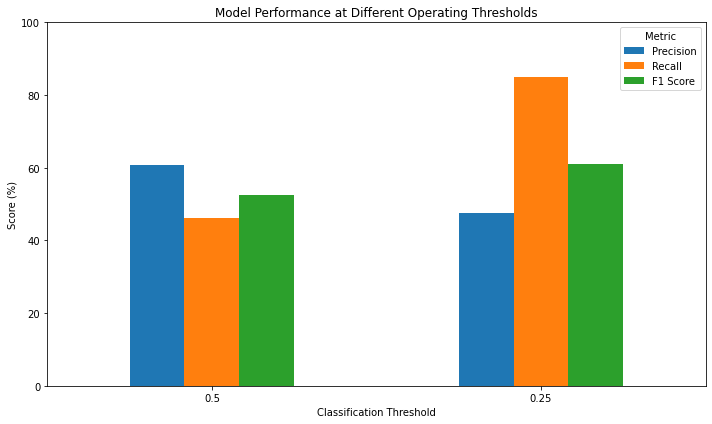

In [79]:
threshold_decision_table.set_index("Threshold")[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance at Different Operating Thresholds")
plt.ylabel("Score (%)")
plt.xlabel("Classification Threshold")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

In [80]:
final_model_recommendation = {
    "Selected Model": "Logistic Regression",
    "Reason 1": "Highest test accuracy among evaluated models",
    "Reason 2": "Highest recall and F1 score among evaluated models",
    "Reason 3": "Provides interpretable feature coefficients",
    "Reason 4": "Supports probability-based risk stratification",
    "Prototype Threshold": 0.25,
    "Prototype Recall": "85.1%",
    "Important Limitation": (
        "The model was developed and evaluated using synthetic data "
        "and requires validation on real-world clinical data before deployment."
    )
}

final_model_recommendation

{'Selected Model': 'Logistic Regression',
 'Reason 1': 'Highest test accuracy among evaluated models',
 'Reason 2': 'Highest recall and F1 score among evaluated models',
 'Reason 3': 'Provides interpretable feature coefficients',
 'Reason 4': 'Supports probability-based risk stratification',
 'Prototype Threshold': 0.25,
 'Prototype Recall': '85.1%',
 'Important Limitation': 'The model was developed and evaluated using synthetic data and requires validation on real-world clinical data before deployment.'}

In [81]:
intervention_list = X_test_large.copy()

intervention_list["Actual Readmission"] = y_test_large.values
intervention_list["Readmission Probability"] = (
    final_model.predict_proba(X_test_large)[:, 1]
)

intervention_list["Intervention Flag"] = (
    intervention_list["Readmission Probability"] >= prototype_threshold
)

intervention_list = intervention_list.sort_values(
    "Readmission Probability",
    ascending=False
)

intervention_list.head(20)

,age,length_of_stay,previous_admissions,chronic_conditions,emergency_visit,Actual Readmission,Readmission Probability,Intervention Flag
709,81,12,5,6,1,1,0.867966,True
309,74,10,5,6,1,1,0.807884,True
664,67,14,4,5,1,1,0.804054,True
463,69,12,4,6,1,1,0.793825,True
368,80,12,2,6,1,0,0.754788,True
992,72,14,3,4,1,0,0.754416,True
860,74,13,4,3,1,0,0.752358,True
355,79,14,1,5,1,0,0.724582,True
826,59,10,5,5,1,1,0.712630,True
754,83,9,5,6,0,1,0.712450,True


In [82]:
intervention_queue = intervention_list[
    intervention_list["Intervention Flag"] == True
].copy()

print("Patients in intervention queue:", len(intervention_queue))
print()
print("Top 10 highest-risk patients:")
intervention_queue.head(10)

Patients in intervention queue: 120

Top 10 highest-risk patients:


,age,length_of_stay,previous_admissions,chronic_conditions,emergency_visit,Actual Readmission,Readmission Probability,Intervention Flag
709,81,12,5,6,1,1,0.867966,True
309,74,10,5,6,1,1,0.807884,True
664,67,14,4,5,1,1,0.804054,True
463,69,12,4,6,1,1,0.793825,True
368,80,12,2,6,1,0,0.754788,True
992,72,14,3,4,1,0,0.754416,True
860,74,13,4,3,1,0,0.752358,True
355,79,14,1,5,1,0,0.724582,True
826,59,10,5,5,1,1,0.712630,True
754,83,9,5,6,0,1,0.712450,True


In [83]:
queue_actual_readmissions = intervention_queue["Actual Readmission"].sum()

queue_precision = (
    queue_actual_readmissions / len(intervention_queue) * 100
)

print("Patients in intervention queue:", len(intervention_queue))
print("Actual readmissions in queue:", queue_actual_readmissions)
print("Percentage of flagged patients who were readmitted:", round(queue_precision, 1), "%")

Patients in intervention queue: 120
Actual readmissions in queue: 57
Percentage of flagged patients who were readmitted: 47.5 %


In [84]:
missed_readmissions = intervention_list[
    (intervention_list["Actual Readmission"] == 1) &
    (intervention_list["Intervention Flag"] == False)
].copy()

print("Actual readmissions missed by the intervention threshold:", len(missed_readmissions))
print()
print("Missed readmissions:")
missed_readmissions

Actual readmissions missed by the intervention threshold: 10

Missed readmissions:


,age,length_of_stay,previous_admissions,chronic_conditions,emergency_visit,Actual Readmission,Readmission Probability,Intervention Flag
835,40,4,5,4,0,1,0.239195,False
773,64,6,2,3,0,1,0.231565,False
991,46,7,0,4,1,1,0.229299,False
690,53,2,0,5,1,1,0.172013,False
153,79,3,0,4,0,1,0.171159,False
518,79,2,0,0,1,1,0.145479,False
474,22,3,1,6,1,1,0.145337,False
891,28,2,4,5,0,1,0.141354,False
595,22,1,5,3,0,1,0.102102,False
774,18,10,2,0,0,1,0.095096,False


In [85]:
true_positives = (
    (intervention_list["Intervention Flag"] == True) &
    (intervention_list["Actual Readmission"] == 1)
).sum()

false_positives = (
    (intervention_list["Intervention Flag"] == True) &
    (intervention_list["Actual Readmission"] == 0)
).sum()

true_negatives = (
    (intervention_list["Intervention Flag"] == False) &
    (intervention_list["Actual Readmission"] == 0)
).sum()

false_negatives = (
    (intervention_list["Intervention Flag"] == False) &
    (intervention_list["Actual Readmission"] == 1)
).sum()

print("True Positives:", true_positives)
print("False Positives:", false_positives)
print("True Negatives:", true_negatives)
print("False Negatives:", false_negatives)

True Positives: 57
False Positives: 63
True Negatives: 70
False Negatives: 10


In [86]:
total_patients = len(intervention_list)

true_positive_rate = true_positives / total_patients * 100
false_positive_rate = false_positives / total_patients * 100
true_negative_rate = true_negatives / total_patients * 100
false_negative_rate = false_negatives / total_patients * 100

print("True Positive Rate:", round(true_positive_rate, 1), "%")
print("False Positive Rate:", round(false_positive_rate, 1), "%")
print("True Negative Rate:", round(true_negative_rate, 1), "%")
print("False Negative Rate:", round(false_negative_rate, 1), "%")

True Positive Rate: 28.5 %
False Positive Rate: 31.5 %
True Negative Rate: 35.0 %
False Negative Rate: 5.0 %


In [87]:
operational_confusion_matrix = pd.DataFrame(
    [
        [true_negatives, false_positives],
        [false_negatives, true_positives]
    ],
    index=["Actually Not Readmitted", "Actually Readmitted"],
    columns=["Not Flagged", "Flagged"]
)

operational_confusion_matrix

,Not Flagged,Flagged
Actually Not Readmitted,70,63
Actually Readmitted,10,57


In [89]:
operational_confusion_matrix = pd.DataFrame(
    [
        [true_negatives, false_positives],
        [false_negatives, true_positives]
    ],
    index=["Actually Not Readmitted", "Actually Readmitted"],
    columns=["Not Flagged", "Flagged"]
)

operational_confusion_matrix

,Not Flagged,Flagged
Actually Not Readmitted,70,63
Actually Readmitted,10,57


In [90]:
executive_intervention_summary = {
    "Prototype Threshold": prototype_threshold,
    "Patients Evaluated": total_patients,
    "Patients Flagged": len(intervention_queue),
    "Percentage Flagged": round(len(intervention_queue) / total_patients * 100, 1),
    "Actual Readmissions": int(intervention_list["Actual Readmission"].sum()),
    "Readmissions Captured": int(true_positives),
    "Readmissions Missed": int(false_negatives),
    "Recall": round(true_positives / (true_positives + false_negatives) * 100, 1),
    "Precision": round(true_positives / (true_positives + false_positives) * 100, 1),
    "False Positives": int(false_positives)
}

executive_intervention_summary

{'Prototype Threshold': 0.25,
 'Patients Evaluated': 200,
 'Patients Flagged': 120,
 'Percentage Flagged': 60.0,
 'Actual Readmissions': 67,
 'Readmissions Captured': 57,
 'Readmissions Missed': 10,
 'Recall': 85.1,
 'Precision': 47.5,
 'False Positives': 63}

In [91]:
patients_per_captured_readmission = (
    len(intervention_queue) / true_positives
)

print(
    "Patients flagged per readmission captured:",
    round(patients_per_captured_readmission, 2)
)

Patients flagged per readmission captured: 2.11


In [92]:
threshold_25_efficiency = patients_flagged_25 / true_positives

threshold_50_true_positives = (
    (intervention_list["Intervention Flag"] == True) &
    (intervention_list["Actual Readmission"] == 1)
).sum()

threshold_50_efficiency = (
    patients_flagged_50 / threshold_50_true_positives
)

print("50% threshold:")
print(
    "Patients flagged per readmission captured:",
    round(threshold_50_efficiency, 2)
)

print()

print("25% threshold:")
print(
    "Patients flagged per readmission captured:",
    round(threshold_25_efficiency, 2)
)

50% threshold:
Patients flagged per readmission captured: 0.89

25% threshold:
Patients flagged per readmission captured: 2.11


In [93]:
threshold_50_true_positives = 31
threshold_25_true_positives = 57

threshold_50_efficiency = patients_flagged_50 / threshold_50_true_positives
threshold_25_efficiency = patients_flagged_25 / threshold_25_true_positives

print("50% threshold:")
print(
    "Patients flagged per readmission captured:",
    round(threshold_50_efficiency, 2)
)

print()

print("25% threshold:")
print(
    "Patients flagged per readmission captured:",
    round(threshold_25_efficiency, 2)
)

50% threshold:
Patients flagged per readmission captured: 1.65

25% threshold:
Patients flagged per readmission captured: 2.11


In [94]:
additional_readmissions_captured = (
    threshold_25_true_positives - threshold_50_true_positives
)

additional_patients_flagged = (
    patients_flagged_25 - patients_flagged_50
)

print(
    "Additional readmissions captured:",
    additional_readmissions_captured
)

print(
    "Additional patients flagged:",
    additional_patients_flagged
)

print(
    "Additional patients flagged per additional readmission captured:",
    round(
        additional_patients_flagged / additional_readmissions_captured,
        2
    )
)

Additional readmissions captured: 26
Additional patients flagged: 69
Additional patients flagged per additional readmission captured: 2.65


In [95]:
business_threshold_comparison = pd.DataFrame({
    "Metric": [
        "Patients Flagged",
        "Percentage of Patients Flagged",
        "Readmissions Captured",
        "Recall",
        "Precision",
        "Patients Flagged per Readmission Captured"
    ],
    "50% Threshold": [
        patients_flagged_50,
        percent_flagged_50,
        threshold_50_true_positives,
        46.3,
        60.8,
        threshold_50_efficiency
    ],
    "25% Threshold": [
        patients_flagged_25,
        percent_flagged_25,
        threshold_25_true_positives,
        85.1,
        47.5,
        threshold_25_efficiency
    ]
})

business_threshold_comparison.round(1)

,Metric,50% Threshold,25% Threshold
0,Patients Flagged,51.0,120.0
1,Percentage of Patients Flagged,25.5,60.0
2,Readmissions Captured,31.0,57.0
3,Recall,46.3,85.1
4,Precision,60.8,47.5
5,Patients Flagged per Readmission Captured,1.6,2.1


In [96]:
prototype_recommendation = {
    "Model": "Logistic Regression",
    "Prototype Threshold": 0.25,
    "Primary Objective": "Prioritize high recall for early intervention",
    "Prototype Recall": "85.1%",
    "Prototype Precision": "47.5%",
    "Patients Flagged": "60.0% of test population",
    "Readmissions Captured": "57 of 67",
    "Operational Tradeoff": (
        "Higher recall requires substantially more patients "
        "to be reviewed by the intervention team."
    ),
    "Deployment Recommendation": (
        "Do not deploy clinically. Validate the model, threshold, "
        "workflow, fairness, calibration, and outcomes using real-world "
        "clinical data before operational use."
    )
}

prototype_recommendation

{'Model': 'Logistic Regression',
 'Prototype Threshold': 0.25,
 'Primary Objective': 'Prioritize high recall for early intervention',
 'Prototype Recall': '85.1%',
 'Prototype Precision': '47.5%',
 'Patients Flagged': '60.0% of test population',
 'Readmissions Captured': '57 of 67',
 'Operational Tradeoff': 'Higher recall requires substantially more patients to be reviewed by the intervention team.',
 'Deployment Recommendation': 'Do not deploy clinically. Validate the model, threshold, workflow, fairness, calibration, and outcomes using real-world clinical data before operational use.'}

In [97]:
prototype_recommendation_table = pd.DataFrame(
    list(prototype_recommendation.items()),
    columns=["Decision Area", "Recommendation"]
)

prototype_recommendation_table

,Decision Area,Recommendation
0,Model,Logistic Regression
1,Prototype Threshold,0.25
2,Primary Objective,Prioritize high recall for early intervention
3,Prototype Recall,85.1%
4,Prototype Precision,47.5%
5,Patients Flagged,60.0% of test population
6,Readmissions Captured,57 of 67
7,Operational Tradeoff,Higher recall requires substantially more pati...
8,Deployment Recommendation,"Do not deploy clinically. Validate the model, ..."


In [98]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test_large,
    final_model.predict_proba(X_test_large)[:, 1],
    n_bins=5,
    strategy="uniform"
)

print("Observed readmission rates:", prob_true)
print("Mean predicted probabilities:", prob_pred)

Observed readmission rates: [0.11864407 0.27142857 0.6        0.44444444 1.        ]
Mean predicted probabilities: [0.13089081 0.29096451 0.50351619 0.68688004 0.82663469]


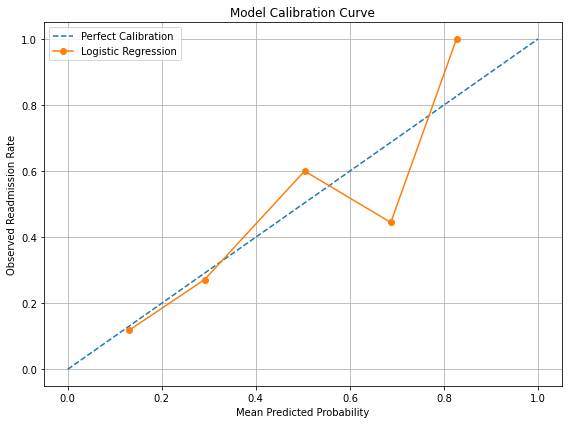

In [99]:
plt.figure(figsize=(8, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.title("Model Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [100]:
from sklearn.metrics import brier_score_loss

test_probabilities = final_model.predict_proba(X_test_large)[:, 1]

brier_score = brier_score_loss(
    y_test_large,
    test_probabilities
)

print("Brier Score:", round(brier_score, 4))

Brier Score: 0.1863


In [101]:
baseline_probability = y_test_large.mean()

baseline_predictions = np.full(
    len(y_test_large),
    baseline_probability
)

baseline_brier_score = brier_score_loss(
    y_test_large,
    baseline_predictions
)

print("Baseline probability:", round(baseline_probability, 4))
print("Baseline Brier Score:", round(baseline_brier_score, 4))
print("Logistic Regression Brier Score:", round(brier_score, 4))

Baseline probability: 0.335
Baseline Brier Score: 0.2228
Logistic Regression Brier Score: 0.1863


In [102]:
brier_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression"
    ],
    "Brier Score": [
        baseline_brier_score,
        brier_score
    ]
})

brier_comparison

,Model,Brier Score
0,Baseline,0.222775
1,Logistic Regression,0.186250


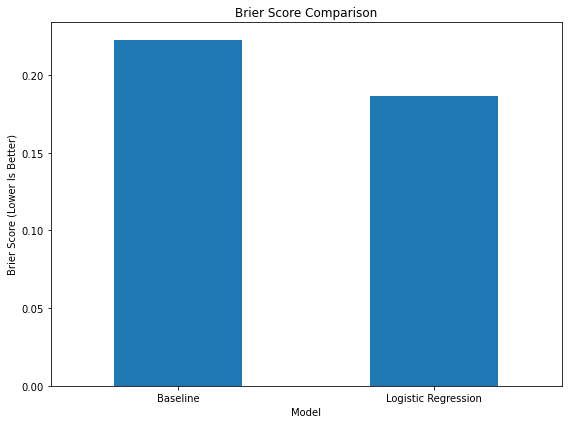

In [103]:
brier_comparison_plot = brier_comparison.set_index("Model")

brier_comparison_plot.plot(
    kind="bar",
    figsize=(8, 6),
    legend=False
)

plt.title("Brier Score Comparison")
plt.ylabel("Brier Score (Lower Is Better)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [104]:
final_model_summary = {
    "Final Model": "Logistic Regression",
    "Test Patients": 200,
    "Test Accuracy": "72.0%",
    "Test Precision at 50%": "60.8%",
    "Test Recall at 50%": "46.3%",
    "Test F1 at 50%": "52.5%",
    "Prototype Threshold": "25%",
    "Prototype Recall": "85.1%",
    "Prototype Precision": "47.5%",
    "Patients Flagged at Prototype Threshold": "60.0%",
    "Readmissions Captured": "57 of 67",
    "Readmissions Missed": "10",
    "High vs Low Risk Ratio": "3.76x",
    "Brier Score": "0.1863",
    "Baseline Brier Score": "0.2228",
    "Primary Limitation": (
        "Model developed and evaluated using synthetic data "
        "and requires validation using real-world clinical data."
    )
}

final_model_summary

{'Final Model': 'Logistic Regression',
 'Test Patients': 200,
 'Test Accuracy': '72.0%',
 'Test Precision at 50%': '60.8%',
 'Test Recall at 50%': '46.3%',
 'Test F1 at 50%': '52.5%',
 'Prototype Threshold': '25%',
 'Prototype Recall': '85.1%',
 'Prototype Precision': '47.5%',
 'Patients Flagged at Prototype Threshold': '60.0%',
 'Readmissions Captured': '57 of 67',
 'Readmissions Missed': '10',
 'High vs Low Risk Ratio': '3.76x',
 'Brier Score': '0.1863',
 'Baseline Brier Score': '0.2228',
 'Primary Limitation': 'Model developed and evaluated using synthetic data and requires validation using real-world clinical data.'}

In [105]:
final_model_summary_table = pd.DataFrame(
    list(final_model_summary.items()),
    columns=["Metric", "Value"]
)

final_model_summary_table

,Metric,Value
0,Final Model,Logistic Regression
1,Test Patients,200
2,Test Accuracy,72.0%
3,Test Precision at 50%,60.8%
4,Test Recall at 50%,46.3%
5,Test F1 at 50%,52.5%
6,Prototype Threshold,25%
7,Prototype Recall,85.1%
8,Prototype Precision,47.5%
9,Patients Flagged at Prototype Threshold,60.0%


In [106]:
prototype_status = {
    "Project": "AI-Powered Predictive Hospital Readmission Prevention System",
    "Prototype Status": "Complete",
    "Model": "Logistic Regression",
    "Data Type": "Synthetic",
    "Test Population": 200,
    "Prototype Threshold": 0.25,
    "Prototype Recall": "85.1%",
    "Prototype Precision": "47.5%",
    "Calibration Assessment": "Completed",
    "Operational Analysis": "Completed",
    "Responsible AI Review": "Completed",
    "Clinical Deployment": "Not Recommended",
    "Next Validation Requirement": (
        "Validate performance, calibration, fairness, workflow impact, "
        "and clinical outcomes using real-world data."
    )
}

prototype_status

{'Project': 'AI-Powered Predictive Hospital Readmission Prevention System',
 'Prototype Status': 'Complete',
 'Model': 'Logistic Regression',
 'Data Type': 'Synthetic',
 'Test Population': 200,
 'Prototype Threshold': 0.25,
 'Prototype Recall': '85.1%',
 'Prototype Precision': '47.5%',
 'Calibration Assessment': 'Completed',
 'Operational Analysis': 'Completed',
 'Responsible AI Review': 'Completed',
 'Clinical Deployment': 'Not Recommended',
 'Next Validation Requirement': 'Validate performance, calibration, fairness, workflow impact, and clinical outcomes using real-world data.'}

In [107]:
final_limitations = [
    "The model was developed and evaluated using synthetic data.",
    "Performance may differ substantially on real-world clinical data.",
    "The prototype threshold has not been clinically validated.",
    "Probability calibration requires further validation on representative data.",
    "Fairness and subgroup performance require evaluation using real patient populations.",
    "The intervention workflow has not been tested in a real clinical environment.",
    "No causal claim can be made that model-guided intervention will reduce readmissions.",
    "Clinical deployment would require appropriate governance, validation, monitoring, and stakeholder approval."
]

for i, limitation in enumerate(final_limitations, start=1):
    print(f"{i}. {limitation}")

1. The model was developed and evaluated using synthetic data.
2. Performance may differ substantially on real-world clinical data.
3. The prototype threshold has not been clinically validated.
4. Probability calibration requires further validation on representative data.
5. Fairness and subgroup performance require evaluation using real patient populations.
6. The intervention workflow has not been tested in a real clinical environment.
7. No causal claim can be made that model-guided intervention will reduce readmissions.
8. Clinical deployment would require appropriate governance, validation, monitoring, and stakeholder approval.


In [108]:
prototype_capabilities = [
    "Predict patient readmission risk using multiple patient-level features.",
    "Compare multiple machine-learning approaches and select an interpretable final model.",
    "Generate probability-based risk scores rather than only binary predictions.",
    "Segment patients into actionable risk categories.",
    "Evaluate different intervention thresholds based on precision and recall trade-offs.",
    "Create an intervention queue for patients exceeding the selected prototype threshold.",
    "Measure how many actual readmissions are captured by the intervention strategy.",
    "Quantify the operational workload associated with different intervention thresholds.",
    "Evaluate probability calibration using a calibration curve and Brier score.",
    "Document limitations and responsible-AI requirements before potential deployment."
]

for i, capability in enumerate(prototype_capabilities, start=1):
    print(f"{i}. {capability}")

1. Predict patient readmission risk using multiple patient-level features.
2. Compare multiple machine-learning approaches and select an interpretable final model.
3. Generate probability-based risk scores rather than only binary predictions.
4. Segment patients into actionable risk categories.
5. Evaluate different intervention thresholds based on precision and recall trade-offs.
6. Create an intervention queue for patients exceeding the selected prototype threshold.
7. Measure how many actual readmissions are captured by the intervention strategy.
8. Quantify the operational workload associated with different intervention thresholds.
9. Evaluate probability calibration using a calibration curve and Brier score.
10. Document limitations and responsible-AI requirements before potential deployment.


In [109]:
project_completion_record = {
    "Project": "AI-Powered Predictive Hospital Readmission Prevention System",
    "Prototype": "Complete",
    "Final Model": "Logistic Regression",
    "Model Selection": "Completed",
    "Model Evaluation": "Completed",
    "Cross-Validation": "Completed",
    "Risk Stratification": "Completed",
    "Threshold Optimization": "Completed",
    "Operational Analysis": "Completed",
    "Calibration Analysis": "Completed",
    "Responsible AI Review": "Completed",
    "Synthetic Data Limitation": "Documented",
    "Clinical Deployment Status": "Not Ready for Deployment",
    "Next Phase": "Consulting Case Study and Post-Build Mastery"
}

project_completion_record

{'Project': 'AI-Powered Predictive Hospital Readmission Prevention System',
 'Prototype': 'Complete',
 'Final Model': 'Logistic Regression',
 'Model Selection': 'Completed',
 'Model Evaluation': 'Completed',
 'Cross-Validation': 'Completed',
 'Risk Stratification': 'Completed',
 'Threshold Optimization': 'Completed',
 'Operational Analysis': 'Completed',
 'Calibration Analysis': 'Completed',
 'Responsible AI Review': 'Completed',
 'Synthetic Data Limitation': 'Documented',
 'Clinical Deployment Status': 'Not Ready for Deployment',
 'Next Phase': 'Consulting Case Study and Post-Build Mastery'}

In [110]:
final_verification = {
    "Final Model": final_model_summary["Final Model"],
    "Test Accuracy": final_model_summary["Test Accuracy"],
    "Prototype Threshold": final_model_summary["Prototype Threshold"],
    "Prototype Recall": final_model_summary["Prototype Recall"],
    "Prototype Precision": final_model_summary["Prototype Precision"],
    "Patients Flagged": final_model_summary["Patients Flagged at Prototype Threshold"],
    "Readmissions Captured": final_model_summary["Readmissions Captured"],
    "Readmissions Missed": final_model_summary["Readmissions Missed"],
    "Brier Score": final_model_summary["Brier Score"],
    "Baseline Brier Score": final_model_summary["Baseline Brier Score"],
    "Deployment Status": project_completion_record["Clinical Deployment Status"]
}

final_verification

{'Final Model': 'Logistic Regression',
 'Test Accuracy': '72.0%',
 'Prototype Threshold': '25%',
 'Prototype Recall': '85.1%',
 'Prototype Precision': '47.5%',
 'Patients Flagged': '60.0%',
 'Readmissions Captured': '57 of 67',
 'Readmissions Missed': '10',
 'Brier Score': '0.1863',
 'Baseline Brier Score': '0.2228',
 'Deployment Status': 'Not Ready for Deployment'}

In [111]:
print("=" * 60)
print("AI-POWERED HOSPITAL READMISSION PREVENTION PROTOTYPE")
print("=" * 60)
print("STATUS: COMPLETE")
print("FINAL MODEL: Logistic Regression")
print("PROTOTYPE THRESHOLD: 25%")
print("PROTOTYPE RECALL: 85.1%")
print("PROTOTYPE PRECISION: 47.5%")
print("TEST POPULATION: 200")
print("READMISSIONS CAPTURED: 57 OF 67")
print("READMISSIONS MISSED: 10")
print("BRIER SCORE: 0.1863")
print("DEPLOYMENT STATUS: NOT READY FOR CLINICAL DEPLOYMENT")
print("=" * 60)

AI-POWERED HOSPITAL READMISSION PREVENTION PROTOTYPE
STATUS: COMPLETE
FINAL MODEL: Logistic Regression
PROTOTYPE THRESHOLD: 25%
PROTOTYPE RECALL: 85.1%
PROTOTYPE PRECISION: 47.5%
TEST POPULATION: 200
READMISSIONS CAPTURED: 57 OF 67
READMISSIONS MISSED: 10
BRIER SCORE: 0.1863
DEPLOYMENT STATUS: NOT READY FOR CLINICAL DEPLOYMENT
